In [2]:
### ground work for spatial plots for paper...
### need 'd2' environment for this not firerx
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from osgeo import gdal
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union
import csv
import sys

In [2]:
### load national forest bounds
nationalforests = gpd.read_file("../data/raw/supplemental/nationalforestboundaries/S_USA.AdministrativeForest.shp")
costate = gpd.read_file("../data/raw/raw_vector/Colorado_State_Boundary/Colorado_State_Boundary.shp")

In [3]:
### 
print(nationalforests.columns)
print(nationalforests["FORESTNAME"])
#print(type(nationalforests["Ig_Date"][0]))
#print(type(nationalforests["geometry"][0]))

print(nationalforests)
print(costate.geometry)

Index(['ADMINFORES', 'REGION', 'FORESTNUMB', 'FORESTORGC', 'FORESTNAME',
       'GIS_ACRES', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry'],
      dtype='object')
0                            El Yunque National Forest
1                                  Savannah River Site
2      Land Between the Lakes National Recreation Area
3                             Chippewa National Forest
4                       Huron-Manistee National Forest
                            ...                       
107                           Mt. Hood National Forest
108                             Ochoco National Forest
109                            Olympic National Forest
110         Francis Marion and Sumter National Forests
111                          National Forests in Texas
Name: FORESTNAME, Length: 112, dtype: object
                               ADMINFORES REGION FORESTNUMB FORESTORGC  \
0                          99081600010343     08         16       0816   
1    99277d9a-c8c4-49c4-aced-d7f8e1d8c78a     0

In [4]:
nationalforests = nationalforests.to_crs(epsg=4326)
costate = costate.to_crs(epsg=4326)
clipped_nfbounds = nationalforests.clip(mask=costate)

In [5]:
print(clipped_nfbounds["FORESTNAME"])

42                               Carson National Forest
38                             San Juan National Forest
35                           Rio Grande National Forest
37                 Pike and San Isabel National Forests
32    Grand Mesa, Uncompahgre and Gunnison National ...
57                         Manti-La Sal National Forest
40                          White River National Forest
36               Arapaho and Roosevelt National Forests
33                   Medicine Bow-Routt National Forest
Name: FORESTNAME, dtype: object


In [6]:
print(len(clipped_nfbounds))

def convert_bbox(i, xy, buffer=0):
    ### [xmax, y_min, x_min, y_max] ???
    if xy == "x":
        return [i[2]+buffer, i[2]+buffer, i[0]-buffer, i[0]-buffer, i[2]+buffer]
    else:
        return[i[1]-buffer, i[3]+buffer, i[3]+buffer, i[1]-buffer, i[1]-buffer]

9


In [7]:
### extract fire areas, bounding_boxes from data
nfsize = np.zeros(len(clipped_nfbounds))
### [xmax, y_min, x_min, y_max]
nf_bbox = np.zeros((len(clipped_nfbounds), 4))
for i in range(len(clipped_nfbounds)):
    nfsize = clipped_nfbounds.iloc[i]["geometry"].area
    nf_bbox[i] = clipped_nfbounds.iloc[i]["geometry"].bounds
### sanity check on fire bounding box extraction
print(nf_bbox[1], clipped_nfbounds.iloc[1]["geometry"].bounds)

[-108.80512116   37.04752859 -106.62157727   37.90538968] (-108.80512116, 37.04752859000001, -106.62157726999999, 37.905389679999985)


/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_78257/513676481.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colorsm = plt.cm.get_cmap('hsv', len(clipped_nfbounds)+1)


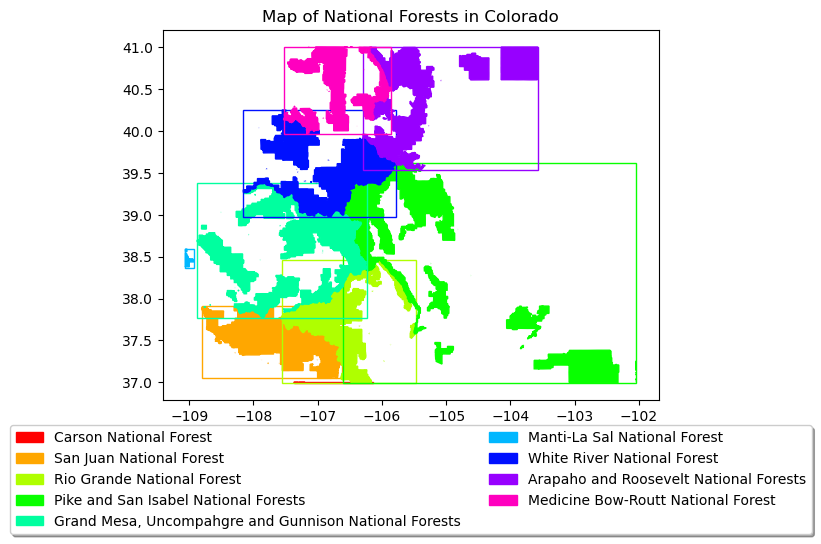

In [8]:
fig, axs = plt.subplots()
colorsm = plt.cm.get_cmap('hsv', len(clipped_nfbounds)+1)

for i in range(len(clipped_nfbounds)):
    firstflag = True
    for geom in clipped_nfbounds.iloc[i]["geometry"].geoms:    
        xsi, ysi = geom.exterior.xy   
        if firstflag:
            #, fc='r', ec='r'
            axs.fill(xsi, ysi, fc=colorsm(i), ec=colorsm(i), label=clipped_nfbounds.iloc[i]["FORESTNAME"])
            firstflag = False
        else:
            axs.fill(xsi, ysi, fc=colorsm(i), ec=colorsm(i))
    axs.fill(convert_bbox(nf_bbox[i], "x"), convert_bbox(nf_bbox[i], "y"), fc="none", ec=colorsm(i))
    #axs.fill(convert_bbox(nf_bbox[i], "x", 2000),convert_bbox(nf_bbox[np.argmax(nfsize)], "y", 2000), fc="none", ec='g', label="Buffered Bounding Box")

#axs.legend()
plt.title("Map of National Forests in Colorado")
axs.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=2)

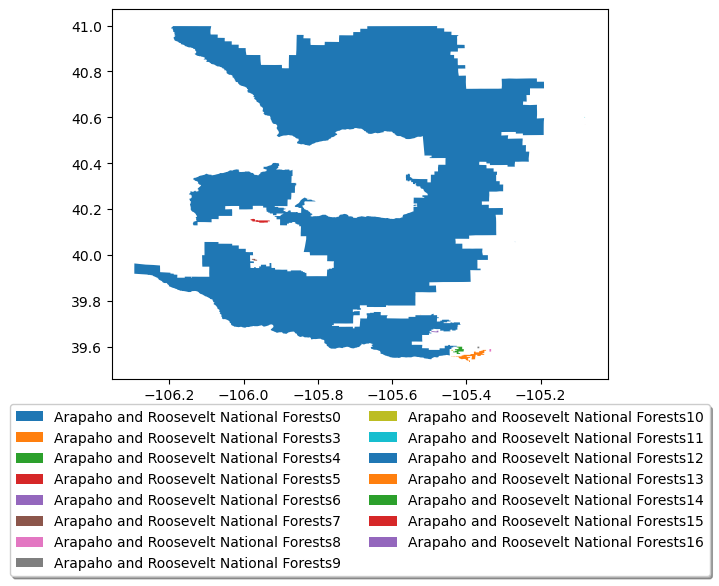

In [9]:
### plotting for subpolygons of specific forests
ploton = 7
fig, axs = plt.subplots()
geomcount = 0
for geom in clipped_nfbounds.iloc[ploton]["geometry"].geoms:
    xsi, ysi = geom.exterior.xy   
    if geomcount not in [1, 2]:
        axs.fill(xsi, ysi, label=clipped_nfbounds.iloc[ploton]["FORESTNAME"] + str(geomcount))
    firstflag = False
    geomcount += 1
axs.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=2)

temp_poly_list = [P for P in clipped_nfbounds.iloc[ploton]["geometry"].geoms ]
aandr_clean = MultiPolygon([temp_poly_list[0]] + temp_poly_list[3:])

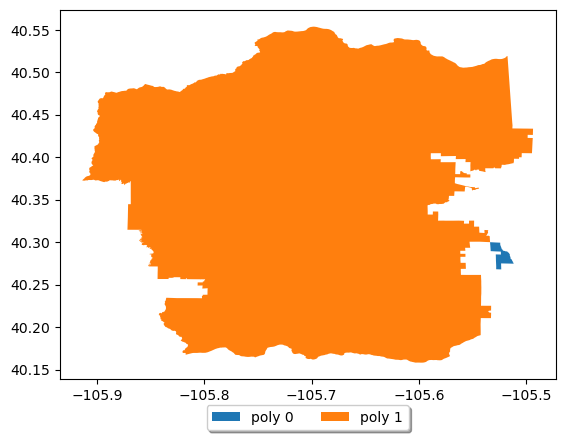

In [10]:
### load and plot rmnp
rmnp = gpd.read_file("../data/raw/supplemental/rmnpboundaries/Boundary_(Polygon).shp")
rmnp = rmnp.to_crs(epsg=4326)
#print(rmnp.columns)
ploton = 0
fig, axs = plt.subplots()
geomcount = 0
for geom in rmnp.iloc[ploton]["geometry"].geoms:
    xsi, ysi = geom.exterior.xy   
    axs.fill(xsi, ysi, label="poly " + str(geomcount))
    geomcount += 1
axs.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=2)

In [11]:
### save selected shapes to shapefile
combined_df = gpd.GeoDataFrame({"AreaName": ["San Juan NF", "White River NF", "Arapaho and Roosevelt NF", "Rocky Mountain NP"],
                                "geometry": [clipped_nfbounds.iloc[1]["geometry"], clipped_nfbounds.iloc[6]["geometry"], aandr_clean, rmnp.iloc[0]["geometry"]]},
                                crs="EPSG:4326")

combined_df.to_file('../data/raw/supplemental/nf_analysis_bds/nf_analysis_bds.shp')

In [12]:
ultimateboundary = gpd.GeoSeries(unary_union(combined_df["geometry"]))

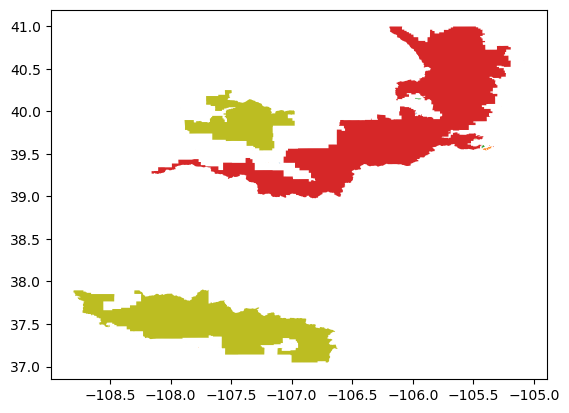

In [13]:
fig, axs = plt.subplots()
for gs in ultimateboundary:
    for geom in gs.geoms:
        xsi, ysi = geom.exterior.xy   
        axs.fill(xsi, ysi, label="poly " + str(geomcount))
#axs.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
#          fancybox=True, shadow=True, ncol=2)

In [14]:
print(clipped_nfbounds["FORESTNAME"])
### run on San Juan, White River, Arapaho and Roosevelt (without grassland), rmnp
### idea: set some layer, eg LF_EVC, to nodata outside of these bounds
### this will lead to cubes generated only in these zones

raster_trim_loc = "../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_EVC_22_mean_4326_0_0"
trim_shape_loc = "../data/raw/supplemental/nf_analysis_bds/nf_analysis_bds.shp"
os.system("gdalwarp -cutline " + trim_shape_loc + " -crop_to_cutline " + raster_trim_loc + ".tif " + raster_trim_loc + "_foresttrim.tif")

42                               Carson National Forest
38                             San Juan National Forest
35                           Rio Grande National Forest
37                 Pike and San Isabel National Forests
32    Grand Mesa, Uncompahgre and Gunnison National ...
57                         Manti-La Sal National Forest
40                          White River National Forest
36               Arapaho and Roosevelt National Forests
33                   Medicine Bow-Routt National Forest
Name: FORESTNAME, dtype: object


ERROR 1: Output dataset ../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_EVC_22_mean_4326_0_0_foresttrim.tif exists,
but some command line options were provided indicating a new dataset
should be created.  Please delete existing dataset and run again.



256

In [15]:
raster_small = gdal.Open(raster_trim_loc + "_foresttrim.tif")
rasterband_small = raster_small.GetRasterBand(1)
nodata_small = rasterband_small.GetNoDataValue()
rastersize_small = (raster_small.RasterXSize, raster_small.RasterYSize)
fullraster_small = raster_small.ReadAsArray().transpose()
#tulh, tpxh, _, tulv, _, tpxv
# tpxv -> abs (tpxv)
geo_small = raster_small.GetGeoTransform()
proj_small = raster_small.GetProjection()
crs_small = [geo_small[0], geo_small[3], geo_small[1], abs(geo_small[5])]

raster_full = gdal.Open(raster_trim_loc + ".tif")
rasterband_full = raster_full.GetRasterBand(1)
nodata_full = rasterband_full.GetNoDataValue()
rastersize_full = (raster_full.RasterXSize, raster_full.RasterYSize)
#tulh, tpxh, _, tulv, _, tpxv
# tpxv -> abs (tpxv)
geo_full = raster_full.GetGeoTransform()
proj_full = raster_full.GetProjection()
crs_full = [geo_full[0], geo_full[3], geo_full[1], abs(geo_full[5])]


### convert from coordinates to indices -- from create_pyramid_functions
def geo_idx(cx, cy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    ix = (cx - ulh) / psh
    iy = (ulv - cy) / psv
    return ix, iy

### convert from indices to coordinates -- same...
def idx_geo(ix, iy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    cx = ulh + (ix * psh)
    cy = ulv - (iy * psv)
    return cx, cy

print(rastersize_small, rastersize_full)

/Users/jega7451/anaconda3/envs/d2/lib/python3.12/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


(13801, 14633) (29803, 18808)


In [16]:
print(rastersize_small)

(13801, 14633)


In [17]:
output_raster = np.zeros(rastersize_full) + nodata_full
print(output_raster.shape)
small_uli, small_ulj = idx_geo(0, 0, crs_small)
diffi, diffj = geo_idx(small_uli, small_ulj, crs_full)
print("offset:", diffi, diffj)
output_raster[int(diffi):int(diffi)+rastersize_small[0], int(diffj):int(diffj)+rastersize_small[1]] = fullraster_small

output_raster[0, 0] = 1
output_raster[-1, 0] = 1
output_raster[0, -1] = 1
output_raster[-1, -1] = 1

driver = gdal.GetDriverByName("GTiff")
out_comp = driver.Create(raster_trim_loc + "_ftc.tif",
                        output_raster.shape[0], output_raster.shape[1], 1, gdal.GDT_Float32)
out_comp.SetGeoTransform(geo_full)
out_comp.SetProjection(proj_full)

out_comp.GetRasterBand(1).WriteArray(output_raster.transpose())
out_comp.GetRasterBand(1).SetNoDataValue(nodata_full)
out_comp.FlushCache()
print(nodata_full)

(29803, 18808)
offset: 3585.0000000000177 1945.9999999999936
-32768.0


In [262]:
### with everything computed here...
### general idea is to load evt, cc, evc, standage wuehat, esihat, agbhat, ...
### sampling is again going to be an issue
### the idea is to sample at a 10m grid (GCF of everything) and average...

ad2 = {"lf_evt": {"loc": "../visualize/geographic/geo_masked.tif", #"loc": "../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_EVT_22_mode_4326_0_0.tif",
                         "res": 30, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}, 
              "lf_cc": {"loc": "../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_CC_22_mean_4326_0_0.tif",
                         "res": 30, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}, 
              "lf_evc": {"loc": "../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_EVC_22_mean_4326_0_0.tif",
                         "res": 30, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}, 
              "standage": {"loc": "../data/aligned_raster/analysis_nf_areas_raster/reprojected/STANDAGE_06_mean_4326_0_0.tif",
                           "res": 1000, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}, 
              "yhat_wue": {"loc": "../visualize/geographic/c2_late_a_pyramid_error_1_wue.tif",
                           "res": 70, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None},
              "yhat_esi": {"loc": "../visualize/geographic/c2_late_a_pyramid_error_1_esi.tif",
                           "res": 70, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}, 
              "yhat_agb": {"loc": "../visualize/geographic/c2_late_a_pyramid_error_1_agb.tif",
                            "res": 1000, "data": None, "crs": None, "ndv": None, "rs": None, "norm": None}}

combined_min = np.genfromtxt("../data/ml_sets/pyramid_v10/norm_layer_mins_combined.csv", delimiter=',')
combined_max = np.genfromtxt( "../data/ml_sets/pyramid_v10/norm_layer_maxs_combined.csv", delimiter=',')
print(len(combined_min), len(combined_max))
combined_ids = {"yhat_wue": 15, "yhat_esi": 16, "yhat_agb": 17}
for ii in combined_ids:
    print(combined_min[combined_ids[ii]], combined_max[combined_ids[ii]])

### from [0, 1] multiply by (xmax-xmin) then add xmin... so 0 -> xmin and 1 -> xmax

18 18
0.01425986923277378 19.98988151550293
0.0013136296765878797 0.9225559830665588
-0.005293718073517084 0.03768699988722801


In [263]:
### pre-work
work_raster_i = gdal.Open(ad2["lf_evt"]["loc"])
work_rasterband_i = work_raster_i.GetRasterBand(1)
work_ndv = work_rasterband_i.GetNoDataValue()
del work_raster_i
del work_rasterband_i
os.system("gdal_footprint -max_points unlimited -overwrite " + ad2["yhat_agb"]["loc"] + " ../visualize/geographic/yhat_mask.shp")
os.system("gdalwarp -overwrite -cutline ../visualize/geographic/yhat_mask.shp -crop_to_cutline " + ad2["lf_evt"]["loc"] + " ../visualize/geographic/geo_masked.tif")
ad2["lf_evt"]["loc"] = "../visualize/geographic/geo_masked.tif"


0...10...20...30...40...50...60...70...80...90...100 - done.


ERROR 5: Source and destination datasets must be different.



In [248]:
### load relevent files for this analysis
for rkey in ad2:
    print("loading from", ad2[rkey]["loc"])
    raster_i = gdal.Open(ad2[rkey]["loc"])
    rasterband_i = raster_i.GetRasterBand(1)
    ad2[rkey]["ndv"] = rasterband_i.GetNoDataValue()
    ad2[rkey]["rs"] = (raster_i.RasterXSize, raster_i.RasterYSize)
    #tulh, tpxh, _, tulv, _, tpxv
    # tpxv -> abs (tpxv)
    geo_i = raster_i.GetGeoTransform()
    ad2[rkey]["crs"] = (geo_i[0], geo_i[3], geo_i[1], abs(geo_i[5]))
    ad2[rkey]["data"] = np.array(raster_i.ReadAsArray().transpose())

    print(" -> read array", ad2[rkey]["data"].shape)

    del rasterband_i
    del raster_i

loading from ../visualize/geographic/geo_masked.tif
 -> read array (21599, 14766)
loading from ../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_CC_22_mean_4326_0_0.tif
 -> read array (29803, 18808)
loading from ../data/aligned_raster/analysis_nf_areas_raster/reprojected/LANDFIRE_EVC_22_mean_4326_0_0.tif
 -> read array (29803, 18808)
loading from ../data/aligned_raster/analysis_nf_areas_raster/reprojected/STANDAGE_06_mean_4326_0_0.tif
 -> read array (905, 553)
loading from ../visualize/geographic/c2_late_a_pyramid_error_1_wue.tif
 -> read array (11142, 6367)
loading from ../visualize/geographic/c2_late_a_pyramid_error_1_esi.tif
 -> read array (11142, 6367)
loading from ../visualize/geographic/c2_late_a_pyramid_error_1_agb.tif
 -> read array (779, 445)


In [249]:
for ii in combined_ids:
    ad2[ii]["data"] = (ad2[ii]["data"] * (combined_max[combined_ids[ii]] - combined_min[combined_ids[ii]])) + combined_min[combined_ids[ii]]

In [250]:
perfarray = {}
print(ad2["lf_evt"]["ndv"])
print(ad2["lf_evt"]["data"].shape)
### gather all different labels in evt
temp_dv = np.argwhere(ad2["lf_evt"]["data"] > ad2["lf_evt"]["ndv"])
print(temp_dv.shape)

-32768.0
(21599, 14766)
(109787060, 2)


In [251]:
### pretty sure that []_list is shape (n, 2) where (i, 0) is x coord etc.
def idx_to_geo_vec(idx_list, geopack, usetype=float):
    ulh, ulv, psh, psv = geopack
    
    geo_ul = np.array(idx_list).astype(float)
    geo_ul[:,0] = (geo_ul[:,0] * psh) + ulh
    geo_ul[:,1] = (-geo_ul[:,1] * psv) + ulv

    return geo_ul.astype(usetype)

def geo_to_idx_vec(geo_list, geopack, usetype=float):
    ulh, ulv, psh, psv = geopack

    idx_ul = np.array(geo_list).astype(float)

    idx_ul[:,0] = (idx_ul[:,0] - ulh) / psh
    idx_ul[:,1] = (ulv - idx_ul[:,1]) / psv

    return idx_ul.astype(usetype)

def geo_idx(cx, cy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    ix = (cx - ulh) / psh
    iy = (ulv - cy) / psv
    return ix, iy

### convert from indices to coordinates -- same...
def idx_geo(ix, iy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    cx = ulh + (ix * psh)
    cy = ulv - (iy * psv)
    return cx, cy

In [7]:
print(ad2["standage"]["crs"])
print(idx_to_geo_vec(np.array([[0, 0]]), ad2["standage"]["crs"]))
print(idx_to_geo_vec(np.array([[1, 1]]), ad2["standage"]["crs"]))
### increasing is (+, -) (psh, psv)

(-109.84419529163193, 41.463763622976174, 0.008997741428571421, 0.008997741428571416)
[[-109.84419529   41.46376362]]
[[-109.83519755   41.45476588]]


In [ ]:
### setup
xkeys = ["lf_cc", "lf_evc", "standage"]
ykeys = ["yhat_wue", "yhat_esi", "yhat_agb"]
corekey = "lf_evt"
corenum = np.argwhere(ad2[corekey]["data"] != ad2[corekey]["ndv"])
standard_res = 30
sampling_res = 10
sr_sr = standard_res/sampling_res
comps = [[[] for ccc in range(len(ykeys))] for cc in range(len(xkeys))]

usesss = np.array(np.array([[sampling_res/standard_res, sampling_res/standard_res]]))
comp_range = np.arange(int(sr_sr)).reshape(int(sr_sr), 1)
comp_offset =  comp_range*usesss

print(len(corenum))
#exploratory_y = geo_to_idx_vec(idx_to_geo_vec(corenum, ad2[corekey]["crs"]), ad2["yhat_agb"]["crs"], int)
#print("step a")
#exploratory_test = np.where(ad2["yhat_agb"]["data"][exploratory_y] != ad2["yhat_agb"]["ndv"])
#print("step b")
#reduced_y = corenum[exploratory_test]
#print(len(reduced_y))


reduce_samplelocs = np.arange(len(corenum)//200)
np.random.shuffle(reduce_samplelocs)
reduced_y = corenum[reduce_samplelocs]
print(len(corenum), len(reduce_samplelocs), len(reduced_y))

"""test_r = np.arange(20).reshape(10, 2)
print(test_r)
test_inter = test_r[:,0] + test_r[:,1]
test_result = np.where((test_inter%3) == 0)
print(test_r[test_result])"""

### idea is to iterate over everywhere that we have forest cover
### ... convert ids to UL coords...
for i in range(len(reduced_y)):
    if i % (len(reduced_y)//50) == 0:
        print(i)
    for k  in range(len(ykeys)):
        for j in range(len(xkeys)):
            
            ### iterate over all ids where we have forest cover
            ### convert ids to geo ULs...
            ### this operation will give the UL of every sample point on the diagonal....
            """ts_ul = idx_to_geo_vec(reduced_y[[i]] + comp_offset, ad2[corekey]["crs"])
            ts_val = ad2[corekey]["data"][reduced_y[i]]
            
            xk_ul = geo_to_idx_vec(ts_ul, ad2[xkeys[j]]["crs"], int)
            yk_ul = geo_to_idx_vec(ts_ul, ad2[ykeys[k]]["crs"], int)

            xtract_x = ad2[xkeys[j]]["data"][xk_ul[:, 0], xk_ul[:, 1]]
            xtract_y = ad2[ykeys[k]]["data"][yk_ul[:, 0], yk_ul[:, 1]]"""

            ts_ul = idx_to_geo_vec(reduced_y[[i]], ad2[corekey]["crs"])
            xk_ul = geo_to_idx_vec(ts_ul, ad2[xkeys[j]]["crs"], int)
            yk_ul = geo_to_idx_vec(ts_ul, ad2[ykeys[k]]["crs"], int)
            xtract_x = ad2[xkeys[j]]["data"][xk_ul[0, 0], xk_ul[0, 1]]
            xtract_y = ad2[ykeys[k]]["data"][yk_ul[0, 0], yk_ul[0, 1]]

            if xtract_x != ad2[xkeys[j]]["ndv"] and xtract_y != ad2[ykeys[k]]["ndv"]:
                comps[j][k].append([ad2[corekey]["data"][reduced_y[i]], xtract_x, xtract_y])

            ### each of these is 3x3...right?
            ### append (xx, xy, ts)
            """
            for ii in range(len(xtract_x)):
                if xtract_x[ii] != ad2[xkeys[j]]["ndv"] and xtract_y[ii] != ad2[ykeys[k]]["ndv"]:
                    comps[j][k].append([ts_val, xtract_x[ii], xtract_y[ii]])"""

            ### what do we want here? a thruple of (standage, xkey_location_value, ykey_location_value...)
            #comps[j][k].append([ts_val,])

        


109787060
109787060 548935 548935
0
10978
21956
32934
43912
54890
65868
76846
87824
98802
109780
120758
131736
142714
153692
164670
175648
186626
197604
208582
219560
230538
241516
252494
263472
274450
285428
296406
307384
318362
329340
340318
351296
362274


: 

In [ ]:
### group all raw srtm layers
srtm_list = []
#"gdal_merge.py -o output.tif -of gtiff " + files_string
if False:
    for wr_root, wr_dirs, wr_files in os.walk("../data/raw/raw_raster/src/raw_srtm"):
        srtm_chunks = " ../data/raw/raw_raster/src/raw_srtm/".join(wr_files)
        os.system("gdal_merge.py -o ../data/raw/raw_raster/merged_srtm.tif -of gtiff ../data/raw/raw_raster/src/raw_srtm/" + srtm_chunks)

N39W108.hgt ../data/raw/raw_raster/src/raw_srtm/N39W109.hgt ../data/raw/raw_raster/src/raw_srtm/N38W108.hgt ../data/raw/raw_raster/src/raw_srtm/N38W109.hgt ../data/raw/raw_raster/src/raw_srtm/N37W103.hgt ../data/raw/raw_raster/src/raw_srtm/N36W106.hgt ../data/raw/raw_raster/src/raw_srtm/N36W107.hgt ../data/raw/raw_raster/src/raw_srtm/N37W102.hgt ../data/raw/raw_raster/src/raw_srtm/N41W108.hgt ../data/raw/raw_raster/src/raw_srtm/N36W105.hgt ../data/raw/raw_raster/src/raw_srtm/N36W104.hgt ../data/raw/raw_raster/src/raw_srtm/N36W110.hgt ../data/raw/raw_raster/src/raw_srtm/N41W109.hgt ../data/raw/raw_raster/src/raw_srtm/N40W108.hgt ../data/raw/raw_raster/src/raw_srtm/N37W105.hgt ../data/raw/raw_raster/src/raw_srtm/N37W110.hgt ../data/raw/raw_raster/src/raw_srtm/N37W104.hgt ../data/raw/raw_raster/src/raw_srtm/N40W109.hgt ../data/raw/raw_raster/src/raw_srtm/N37W106.hgt ../data/raw/raw_raster/src/raw_srtm/N36W103.hgt ../data/raw/raw_raster/src/raw_srtm/N36W102.hgt ../data/raw/raw_raster/src/r

In [264]:
evt_metadata_cats = {}
with open("../data/raw/raw_raster/src/LF2022_EVT_230_CONUS/CSV_Data/LF22_EVT_230.csv") as csv_file:
    csv_read=csv.reader(csv_file, delimiter=',')
    firstflag = False
    for row in csv_read:
        #print(row)
        if firstflag:
            evt_metadata_cats[int(row[0])] = [row[1], float(row[13])/255, float(row[14])/255, float(row[15])/255]
        else:
            firstflag = True
for k in evt_metadata_cats:
    print(k, evt_metadata_cats[k])

-9999 ['Fill-NoData', 1.0, 1.0, 1.0]
4401 ['Alaska Arctic Coastal Sedge-Dwarf-Shrubland', 1.0, 0.803921568627451, 0.4392156862745098]
4402 ['Alaska Arctic Floodplain Forest', 0.07058823529411765, 0.2980392156862745, 0.5294117647058824]
4403 ['Alaska Arctic Large River Floodplain Forest', 0.07058823529411765, 0.2980392156862745, 0.5294117647058824]
4404 ['Alaska Arctic Mesic Alder Shrubland', 0.5725490196078431, 0.9294117647058824, 0.8784313725490196]
4405 ['Alaska Arctic Permafrost Plateau Dwarf-Shrub Lichen Tundra', 1.0, 0.1450980392156863, 0.050980392156862744]
4406 ['Alaska Arctic Tidal Flat', 1.0, 0.6, 0.0392156862745098]
4407 ['Alaska Sub-boreal and Maritime Alpine Mesic Herbaceous Meadow', 1.0, 0.8274509803921568, 0.4666666666666667]
4408 ['Alaska Sub-boreal Mesic Subalpine Alder Shrubland', 0.5725490196078431, 0.9294117647058824, 0.8784313725490196]
4409 ['Alaska Sub-boreal Mountain Hemlock-White Spruce Forest', 0.7137254901960784, 0.9803921568627451, 0.8901960784313725]
4410 ['

In [ ]:
comps = np.load('../visualize/geographic/comparicomputations.npy')
print("loaded")

### need to split, for each plot, into evt segments
uniqueset = {}
for i in range(len(comps)):
    if comps[i][0] not in uniqueset:
        uniqueset[comps[i][0]] = [[], evt_metadata_cats[comps[i][0]]]
    else:
        uniqueset[comps[i][0]][0].append(comps[i])

print(len(uniqueset.keys()))
evt_keys = list(uniqueset.keys())
for colork in evt_keys:
    uniqueset[colork][0] = np.array(uniqueset[colork][0])
    print(uniqueset[colork][0].shape)

loaded
102
(20395999, 7)
(2989095, 7)
(6594544, 7)
(6830481, 7)
(1353467, 7)
(2956566, 7)
(2690331, 7)
(12377463, 7)
(1581066, 7)
(12867732, 7)
(146133, 7)
(12847742, 7)
(490463, 7)
(434469, 7)
(597361, 7)
(7840915, 7)
(2834876, 7)
(1150241, 7)
(117007, 7)
(200341, 7)
(170562, 7)
(960451, 7)
(139631, 7)
(571952, 7)
(367740, 7)
(700240, 7)
(394692, 7)
(66477, 7)
(700196, 7)
(219987, 7)
(421962, 7)
(582585, 7)
(633478, 7)
(87906, 7)
(96130, 7)
(279987, 7)
(404929, 7)
(825579, 7)
(254517, 7)
(155400, 7)
(199340, 7)
(78302, 7)
(29039, 7)
(17603, 7)
(133043, 7)
(72375, 7)
(2136, 7)
(121372, 7)
(453133, 7)
(25028, 7)
(71048, 7)
(152516, 7)
(170301, 7)
(99849, 7)
(34040, 7)
(71060, 7)
(12084, 7)
(13414, 7)
(4296, 7)
(2528, 7)
(17205, 7)
(40485, 7)
(28961, 7)
(4904, 7)
(12866, 7)
(27098, 7)
(19882, 7)
(16886, 7)
(17403, 7)
(6218, 7)
(10781, 7)
(11937, 7)
(9930, 7)
(4384, 7)
(10756, 7)
(4945, 7)
(1930, 7)
(22464, 7)
(2795, 7)
(5591, 7)
(8238, 7)
(2159, 7)
(1689, 7)
(8168, 7)
(4144, 7)
(911, 7)


In [266]:
freq = []
names = []
print(len(comps))
for colork in evt_keys:
    #print(uniqueset[colork][1][0], len(uniqueset[colork][0])/ len(comps))
    freq.append(len(uniqueset[colork][0]))
    names.append(uniqueset[colork][1][0])

freq = np.array(freq)
argsrted = np.argsort(-freq)
sumpct = 0
for i in range(len(freq)):
    print(names[argsrted[i]], freq[argsrted[i]] / len(comps))
    sumpct += freq[argsrted[i]]
    if i == 7:
        print(sumpct / len(comps))
    if i == 12:
        print(sumpct / len(comps))

reduced_keys = []
reduced_names = []
reduced_pct = []
#reduced_set = {}
for i in range(8):
    reduced_names.append(names[argsrted[i]])
    reduced_keys.append(evt_keys[argsrted[i]])
    reduced_pct.append(float(freq[argsrted[i]] / len(comps)))
#reduced_pct = np.array(reduced_pct).astype(float)

107403136
Rocky Mountain Subalpine Dry-Mesic Spruce-Fir Forest and Woodland 0.1899013358418138
Colorado Plateau Pinyon-Juniper Woodland 0.11980778661807417
Rocky Mountain Aspen Forest and Woodland 0.1196216654232517
Southern Rocky Mountain Ponderosa Pine Woodland 0.11524303163736299
Rocky Mountain Lodgepole Pine Forest 0.07300452567790944
Southern Rocky Mountain Dry-Mesic Montane Mixed Conifer Forest and Woodland 0.06359666257789717
Rocky Mountain Gambel Oak-Mixed Montane Shrubland 0.06139992038966162
Southern Rocky Mountain Pinyon-Juniper Woodland 0.027830611947867148
0.770405540113838
Inter-Mountain Basins Montane Sagebrush Steppe 0.02752774369642242
Southern Rocky Mountain Mesic Montane Mixed Conifer Forest and Woodland 0.026394722776064937
Southern Rocky Mountain Montane-Subalpine Grassland 0.025048905462127288
Inter-Mountain Basins Big Sagebrush Shrubland 0.014720855078198088
Rocky Mountain Subalpine-Montane Mesic Meadow 0.012601745632455277
0.8766995127591061
Rocky Mountain Lower

In [267]:
for i in range(len(reduced_pct)):
    reduced_pct[i] *= 100

Text(0.5, 1.0, 'Existing Vegetation Type Frequency (Top 8)')

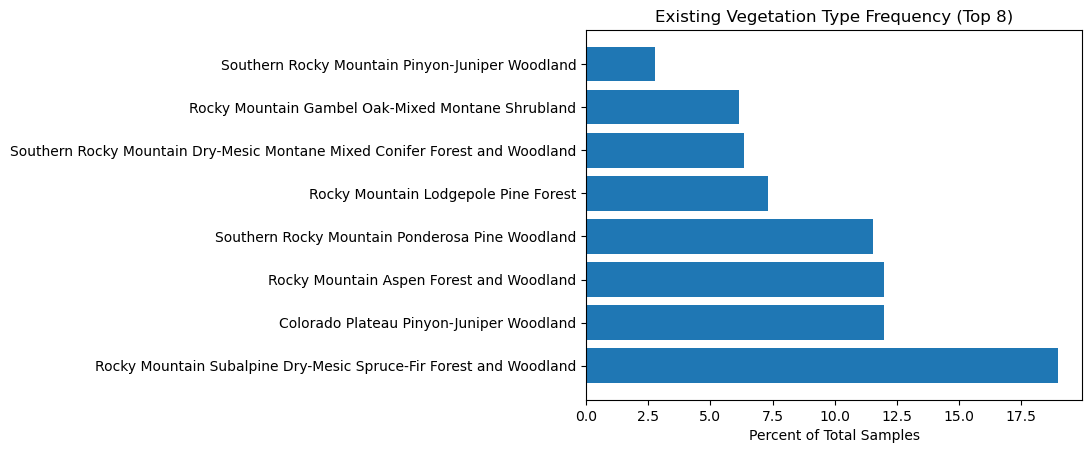

In [268]:
plt.barh(reduced_names, reduced_pct)
plt.xlabel("Percent of Total Samples")
plt.title("Existing Vegetation Type Frequency (Top 8)")

lf_cc yhat_wue
lf_cc yhat_esi
lf_cc yhat_agb
lf_evc yhat_wue
lf_evc yhat_esi
lf_evc yhat_agb
standage yhat_wue
standage yhat_esi
standage yhat_agb


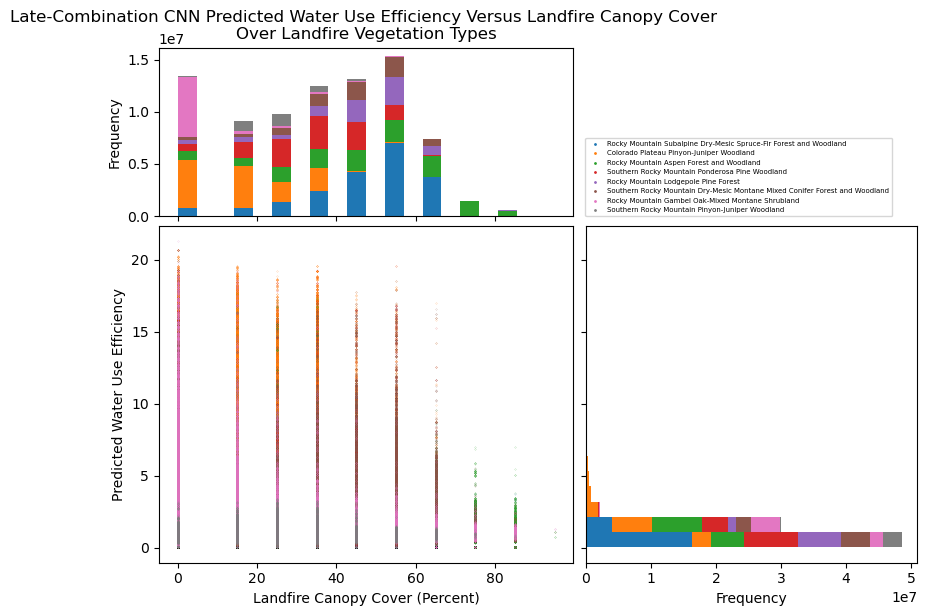

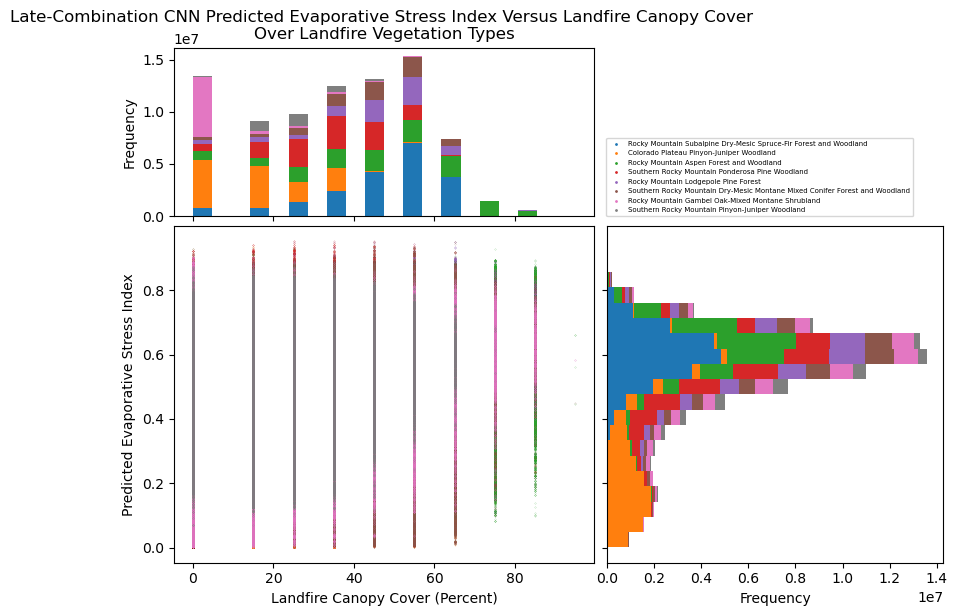

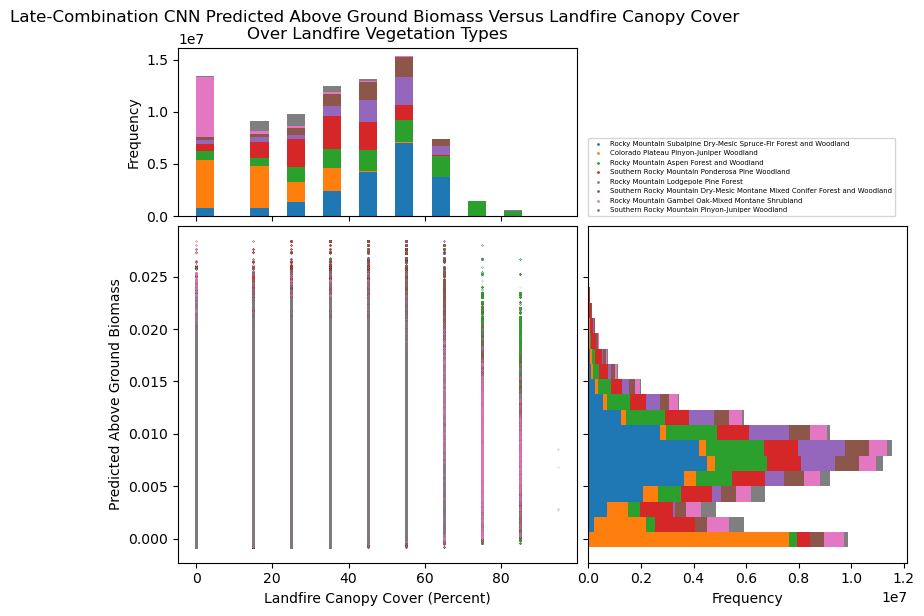

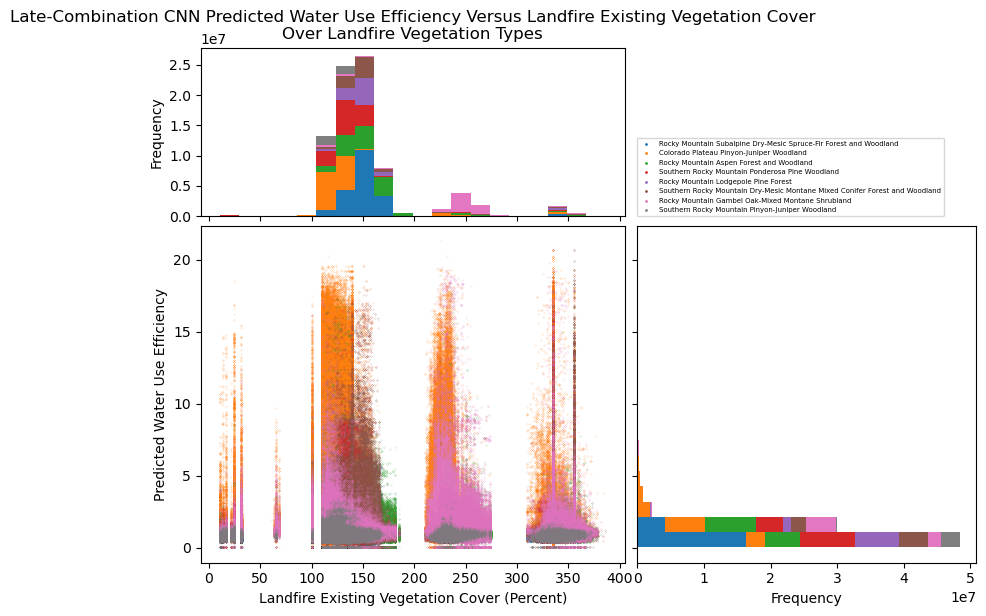

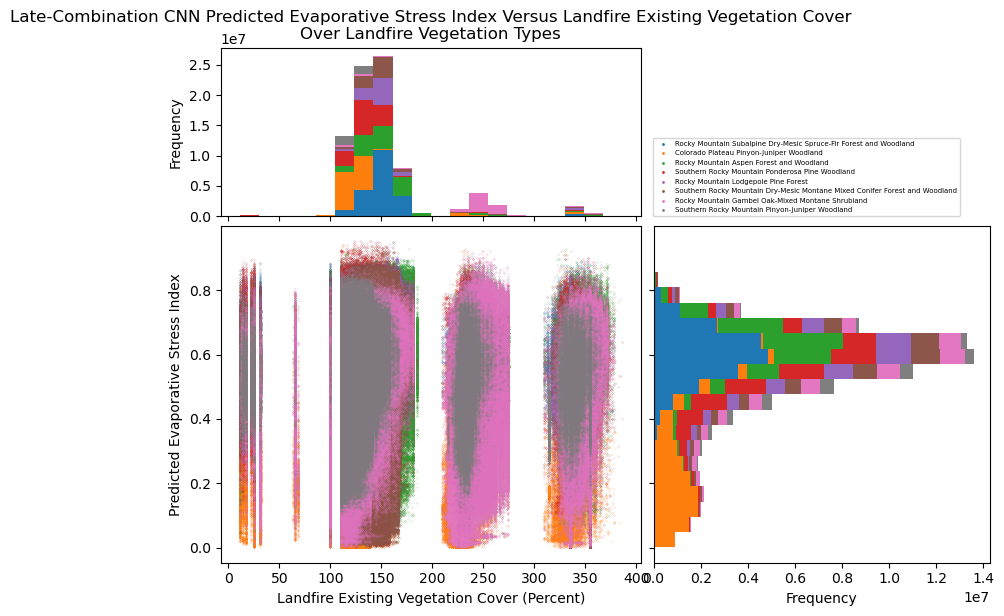

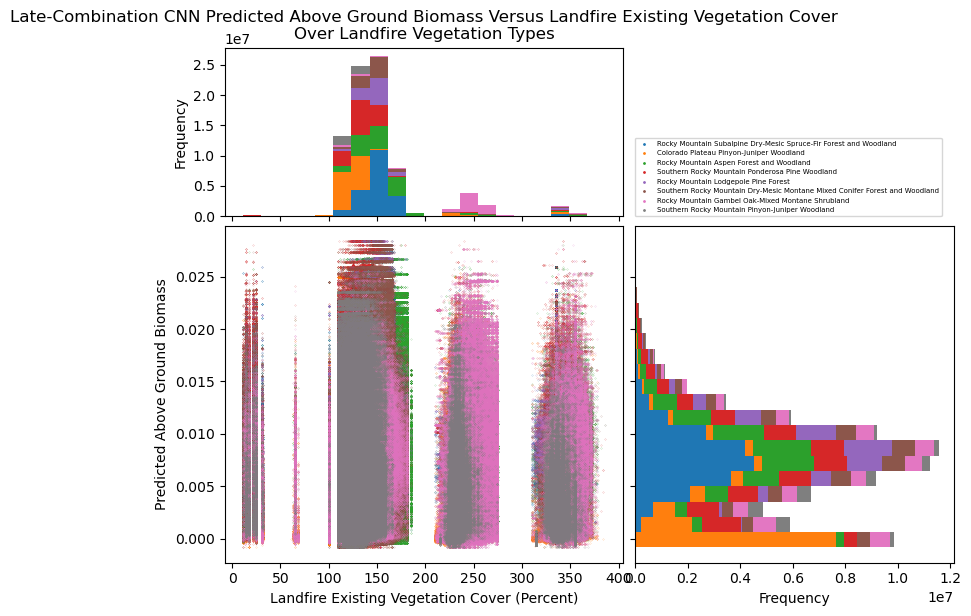

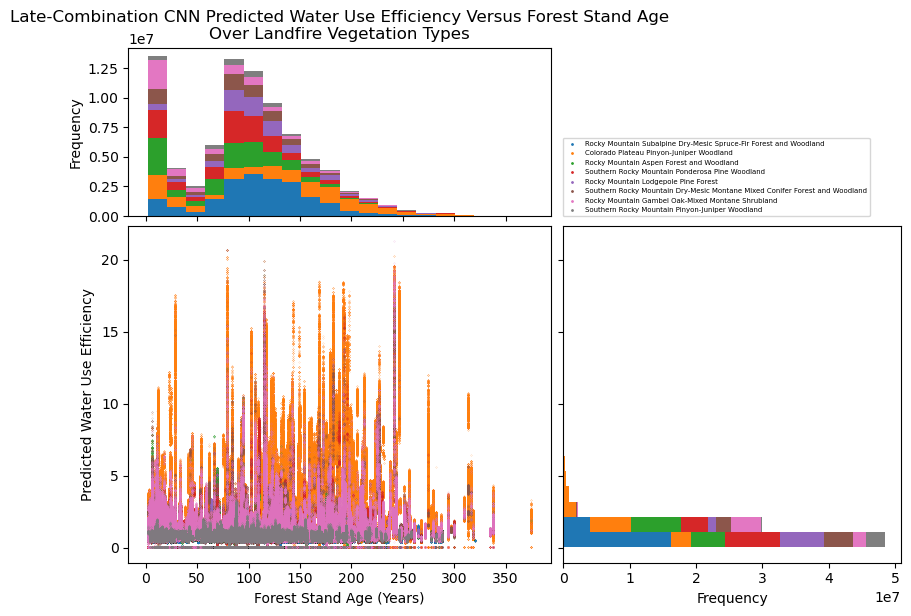

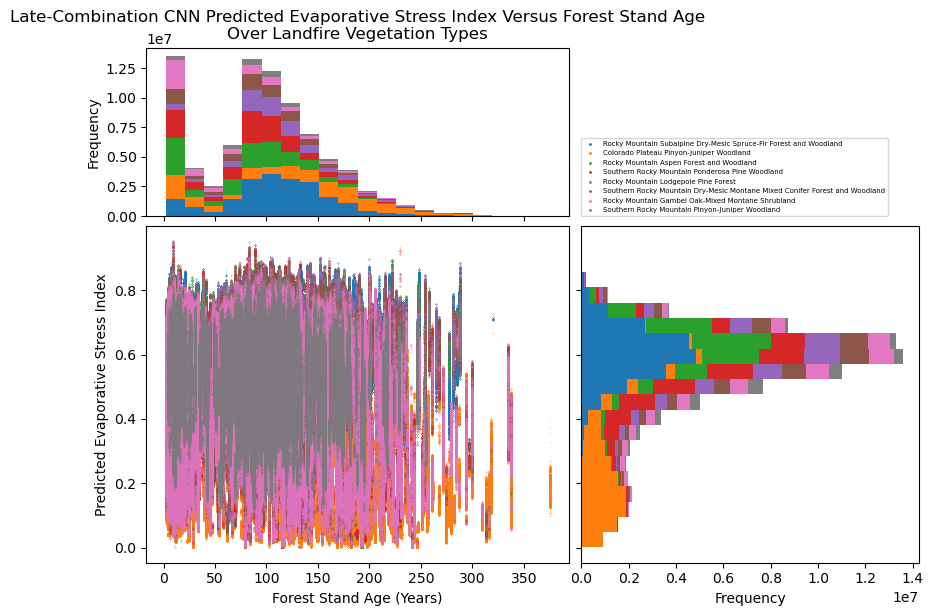

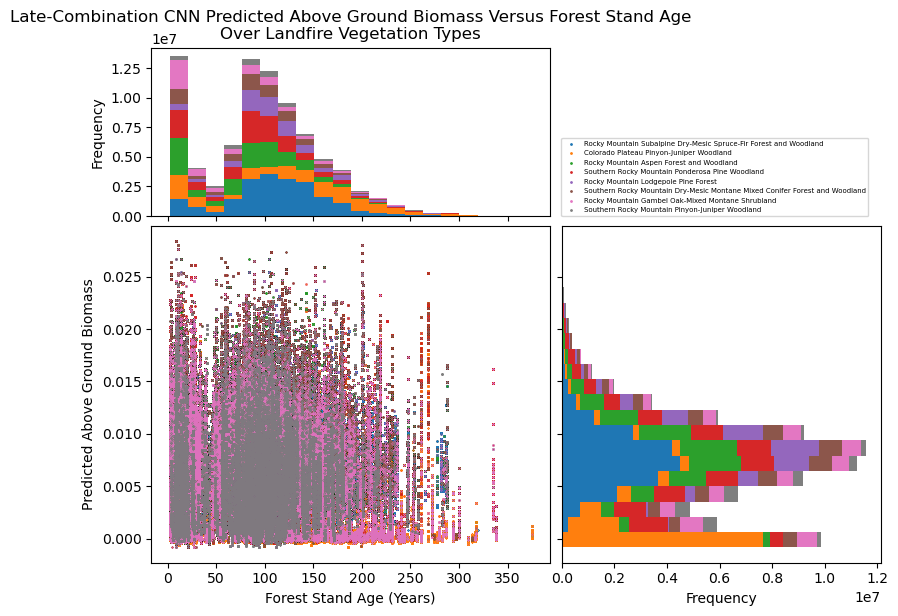

In [270]:
xkeys = ["lf_cc", "lf_evc", "standage"]
ykeys = ["yhat_wue", "yhat_esi", "yhat_agb"]
nice_x_names = ["Landfire Canopy Cover (Percent)", "Landfire Existing Vegetation Cover (Percent)", "Forest Stand Age (Years)"]
nice_y_names = ["Predicted Water Use Efficiency", "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass"]
nice_x_title = ["Landfire Canopy Cover ", "Landfire Existing Vegetation Cover", "Forest Stand Age"]
#nice_y_title = ["Predicted Water Use Efficiency", "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass"]

#colorsm = plt.cm.get_cmap('hsv', len(clipped_nfbounds)+1)
nbins_each = 20

for xkey in range(len(xkeys)):
    for ykey in range(len(ykeys)):
        ### fc=colorsm(i)
        fig = plt.figure(layout='constrained', figsize=(8, 6))
        ax = fig.add_subplot()
        #ax.set_aspect('equal')
        ax_histx = ax.inset_axes([0, 1.03, 1, 0.5], sharex=ax)
        ax_histy = ax.inset_axes([1.03, 0, 0.8, 1], sharey=ax)
        #ax_histy = ax.inset_axes([1.03, 0, 0.5, 1], sharey=ax)

        # no labels
        ax_histx.tick_params(axis="x", labelbottom=False)
        ax_histy.tick_params(axis="y", labelleft=False)

        tempxhist = []
        tempxcols = []
        tempyhist = []
        tempycols = []
        for colork in reduced_keys:
            ax.scatter(uniqueset[colork][0][:,xkey+4], uniqueset[colork][0][:,ykey+1], s=0.01, label=uniqueset[colork][1][0])#, color=(uniqueset[colork][1][1], uniqueset[colork][1][2], uniqueset[colork][1][3], 1))

            tempxhist.append(uniqueset[colork][0][:,xkey+4])
            tempxcols.append((uniqueset[colork][1][1], uniqueset[colork][1][2], uniqueset[colork][1][3], 1))
            tempyhist.append(uniqueset[colork][0][:,ykey+1])
            tempycols.append((uniqueset[colork][1][1], uniqueset[colork][1][2], uniqueset[colork][1][3], 1))

        print(xkeys[xkey], ykeys[ykey])

        ax_histx.hist(tempxhist, nbins_each, histtype='bar', stacked=True, log=False)#, color=tempxcols) #density=True
        ax_histy.hist(tempyhist, nbins_each, histtype='bar', stacked=True, log=False, orientation='horizontal')#, color=tempycols)
        
        ax.set_xlabel(nice_x_names[xkey])
        ax.set_ylabel(nice_y_names[ykey])
        ax_histx.set_ylabel("Frequency")
        ax_histy.set_xlabel("Frequency")
        plt.title("Late-Combination CNN " + nice_y_names[ykey] + " Versus " + nice_x_title[xkey] + "\nOver Landfire Vegetation Types")
        #plt.savefig("../visualize/covars/" + xkeys[xkey] + "_" + ykeys[ykey] + "slick.png", bbox_inches = 'tight')
        #plt.show()
        #sys.exit(0)
        ax.legend(loc='lower left', bbox_to_anchor=(1.02, 1.02), prop={'size': 5},markerscale=10)
        plt.savefig("../visualize/covars/" + xkeys[xkey] + "_" + ykeys[ykey] + "comp.png", bbox_inches = 'tight')
       
            

In [3]:
### need to load in all the rasters and make nice images out of them jesus

### FIRST STEP IN RASTERIZING
geoperf_locs = ["../visualize/geographic/c2_late_a_pyramid_error_1_wue.tif",
                "../visualize/geographic/c2_late_a_pyramid_predictions_1_wue.tif",
                "../visualize/geographic/c2_late_a_pyramid_error_1_esi.tif",
                "../visualize/geographic/c2_late_a_pyramid_predictions_1_esi.tif",
                "../visualize/geographic/c2_late_a_pyramid_error_1_agb.tif",
                "../visualize/geographic/c2_late_a_pyramid_predictions_1_agb.tif"]
                
geoperf_rasters = []
geoperf_ndv = []
geoperf_quantiles = []

for gploc in geoperf_locs:
    print("loading from", gploc)
    gpraster = gdal.Open(gploc)
    gpband = gpraster.GetRasterBand(1)

    geoperf_ndv.append(gpband.GetNoDataValue())
    geoperf_rasters.append(np.array(gpraster.ReadAsArray().transpose()))
    print(" -> read array", geoperf_rasters[-1].shape)
    
    ### trim to remove extra ndv ...
    tempndv = np.argwhere(geoperf_rasters[-1] != geoperf_ndv[-1])
    tq = geoperf_rasters[-1][tempndv]
    print("tq shape", tq.shape)
    geoperf_quantiles.append(np.quantile(tq, [0.25, 0.5, 0.75]))
    x_min, y_min = tempndv.min(axis=0)
    x_max, y_max = tempndv.max(axis=0)
    geoperf_rasters[-1] = geoperf_rasters[-1][x_min:x_max+1, y_min:y_max+1]
    print(" -> cropped to", geoperf_rasters[-1].shape)

combined_min = np.genfromtxt("../data/ml_sets/pyramid_v10/norm_layer_mins_combined.csv", delimiter=',')
combined_max = np.genfromtxt( "../data/ml_sets/pyramid_v10/norm_layer_maxs_combined.csv", delimiter=',')
print(len(combined_min), len(combined_max))
combined_ids2 = {1: 15, 
                 0: 15, 
                 3: 16, 
                 2: 16, 
                 4: 17, 
                 5: 17}
for ii in combined_ids:
    print(combined_min[combined_ids[ii]], combined_max[combined_ids[ii]])


for ii in range(len(geoperf_rasters)//2):
    ### actually, as far as error goes...
    ### if x in [0, 1] and error is (x1 - x2)^2
    ### now scale to [a, b]: error scales with (a-b)^2
    geoperf_rasters[(ii*2) + 1] = (geoperf_rasters[(ii*2) + 1] * (combined_max[combined_ids2[(ii*2) + 1]] - combined_min[combined_ids2[(ii*2) + 1]])) + combined_min[combined_ids2[(ii*2) + 1]]
    print(" -> scaled to", combined_min[combined_ids2[(ii*2)]], combined_max[combined_ids2[(ii*2)]])
    geoperf_rasters[(ii*2)] = geoperf_rasters[(ii*2)] * ((combined_max[combined_ids2[(ii*2)]] - combined_min[combined_ids2[(ii*2)]]) ** 2)


loading from ../visualize/geographic/c2_late_a_pyramid_error_1_wue.tif


/Users/jega7451/anaconda3/envs/d2/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


 -> read array (11142, 6367)


: 

In [401]:
plt_titles = ["Late-Combination WUE Error",
              "Late-Combination WUE Predictions",
              "Late-Combination ESI Error",
              "Late-Combination ESI Predictions",
              "Late-Combination AGB Error",
              "Late-Combination AGB Predictions"]

plt_save = ["wue_error",
            "wue_predictions",
            "esi_error",
            "esi_predictions",
            "agb_error",
            "agb_predictions"]
#nice_y_names = ["Predicted Water Use Efficiency \n (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)", 
#                "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass \n (Mg ha$\mathregular{^{-1}}$)"]

plt_units = ["WUE MSE", "WUE Predictions (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)", 
             "ESI MSE", "ESI Predictions", 
             "AGB MSE", "AGB Predictions (Mg ha$\mathregular{^{-1}}$)"]

textlabels = ["B", "A", "D", "C", "F", "E"]
labelpad = [-46, -45, -52, -45, -62, -60]

for i in range(len(geoperf_rasters)):
    #fig, ax = plt.subplots()
    plt.imshow(geoperf_rasters[i].transpose(), cmap='plasma_r', interpolation='nearest')
    plt.axis('off')
    plt.annotate(textlabels[i], xy=(0.85, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', horizontalalignment='right', fontfamily='serif',
        bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
    #plt.title(plt_titles[i])
    cbar = plt.colorbar(fraction=0.025, pad=-0.15)
    cbar.set_label(plt_units[i], rotation=90, labelpad=labelpad[i])
    plt.savefig("../visualize/realgeoplots/" + plt_save[i] + ".png", bbox_inches = 'tight')
    plt.close()
    

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/1020090600.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt_units = ["WUE MSE", "WUE Predictions (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)",
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/1020090600.py:19: SyntaxWarning: invalid escape sequence '\m'
  "AGB MSE", "AGB Predictions (Mg ha$\mathregular{^{-1}}$)"]


In [212]:
nine_keys = []
nine_names = []
nine_pct = []
#reduced_set = {}
for i in range(9):
    nine_names.append(names[argsrted[i]])
    nine_keys.append(evt_keys[argsrted[i]])
    nine_pct.append(float(freq[argsrted[i]] / len(comps)))

/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/2995815592.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colorsm = plt.cm.get_cmap('hsv', 9)


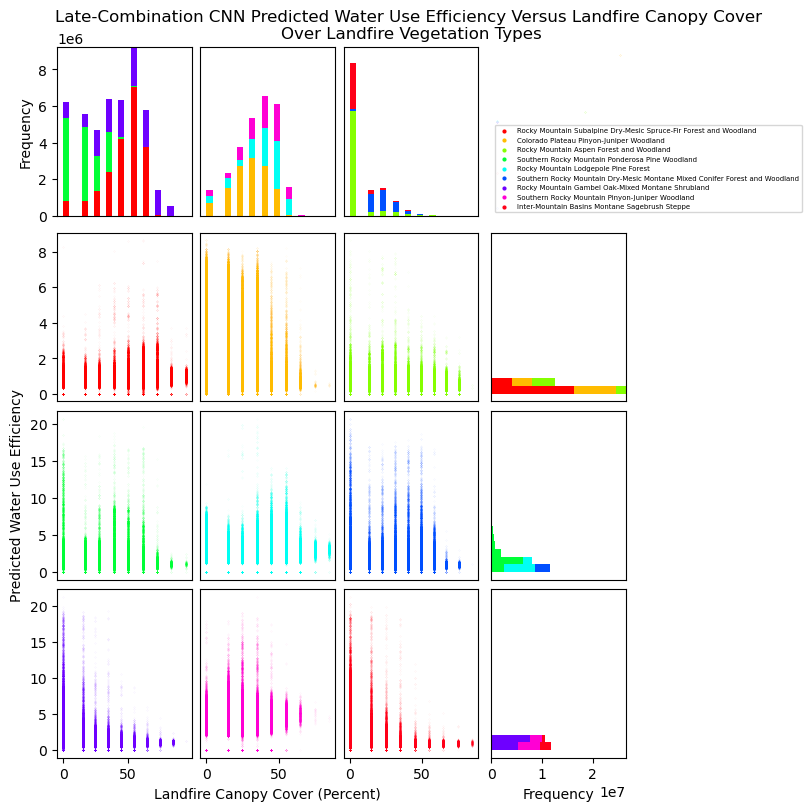

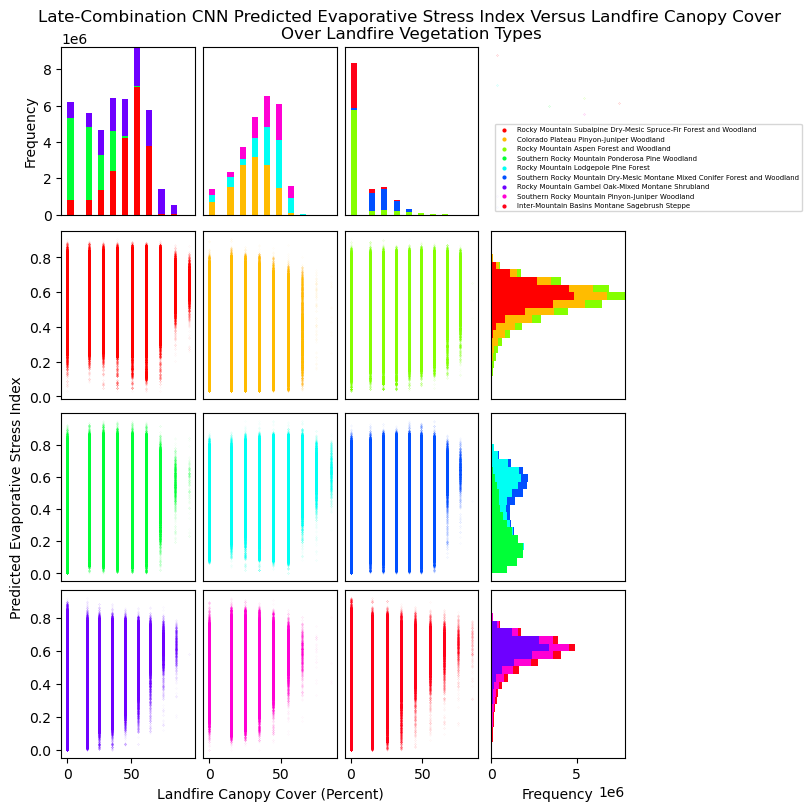

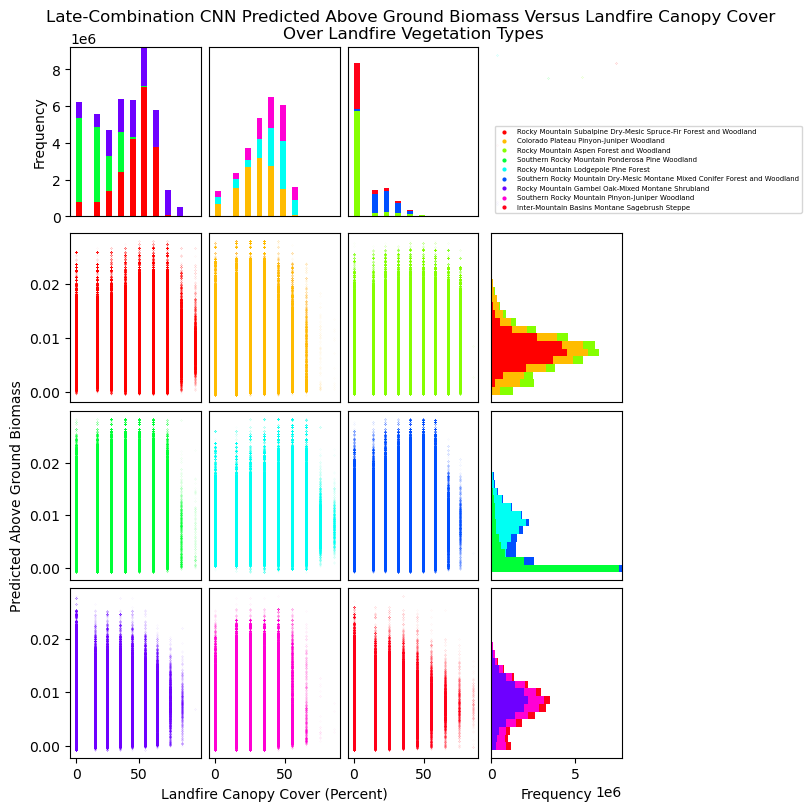

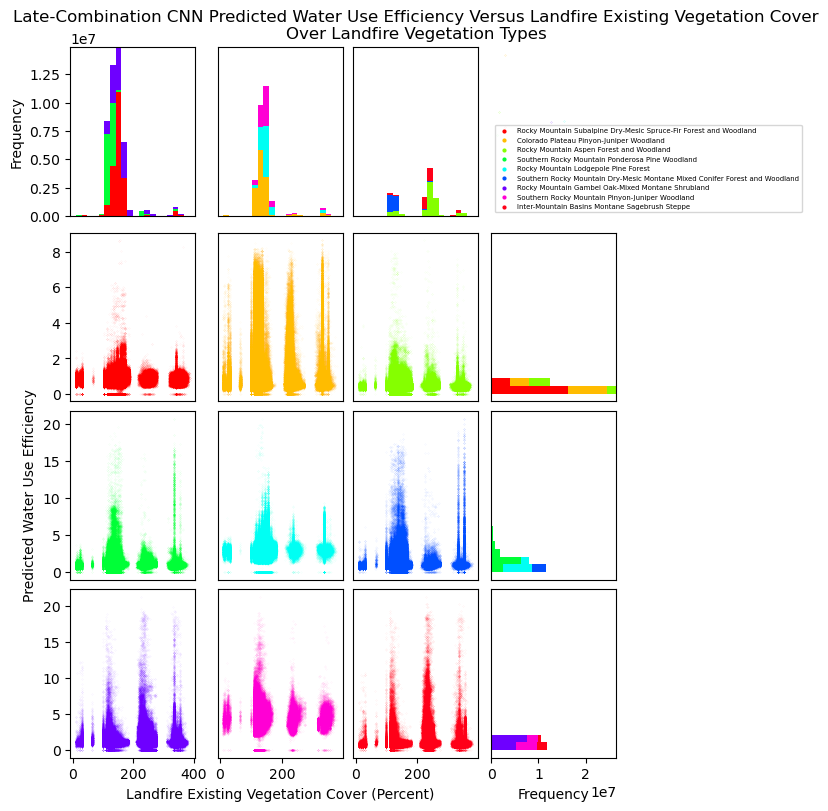

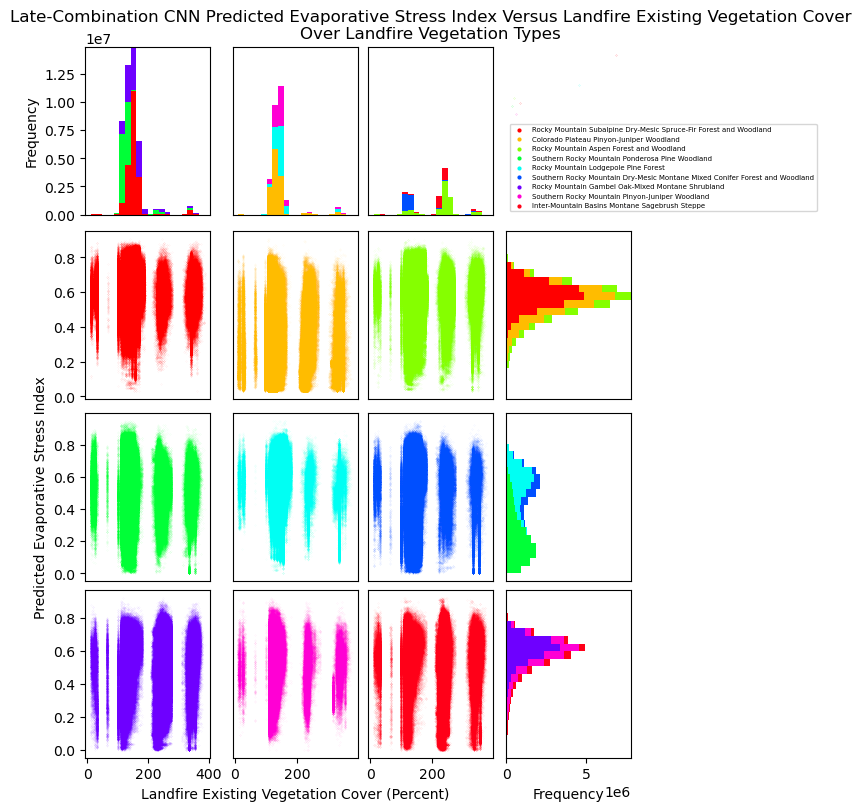

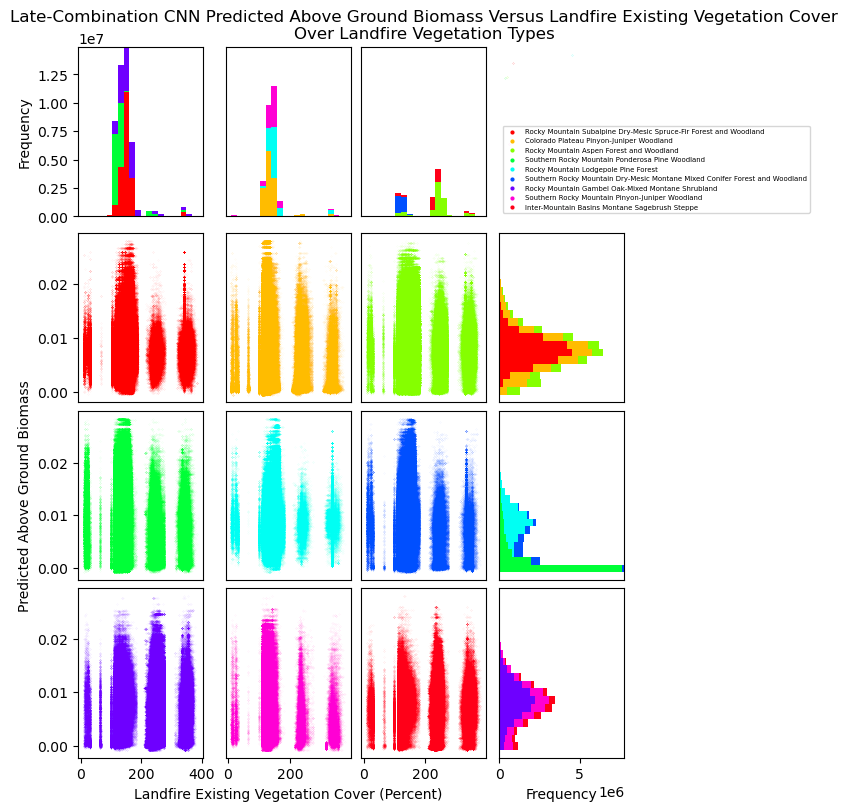

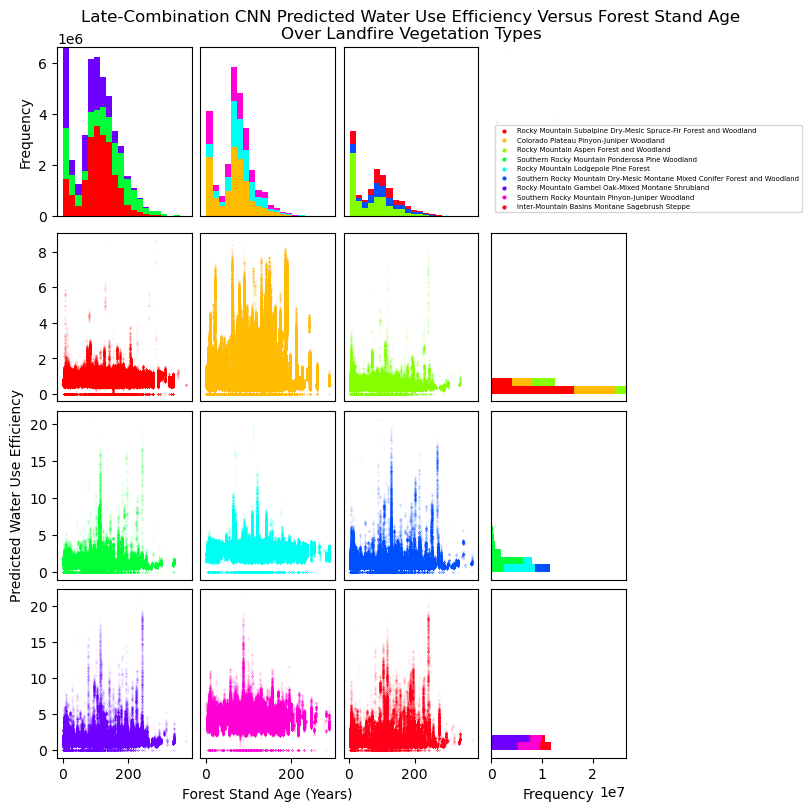

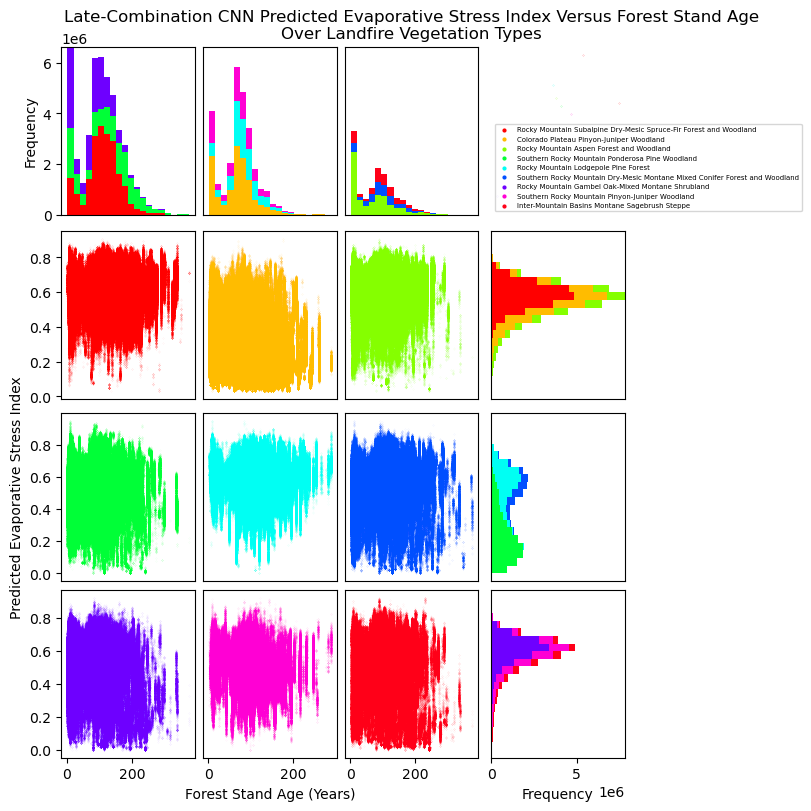

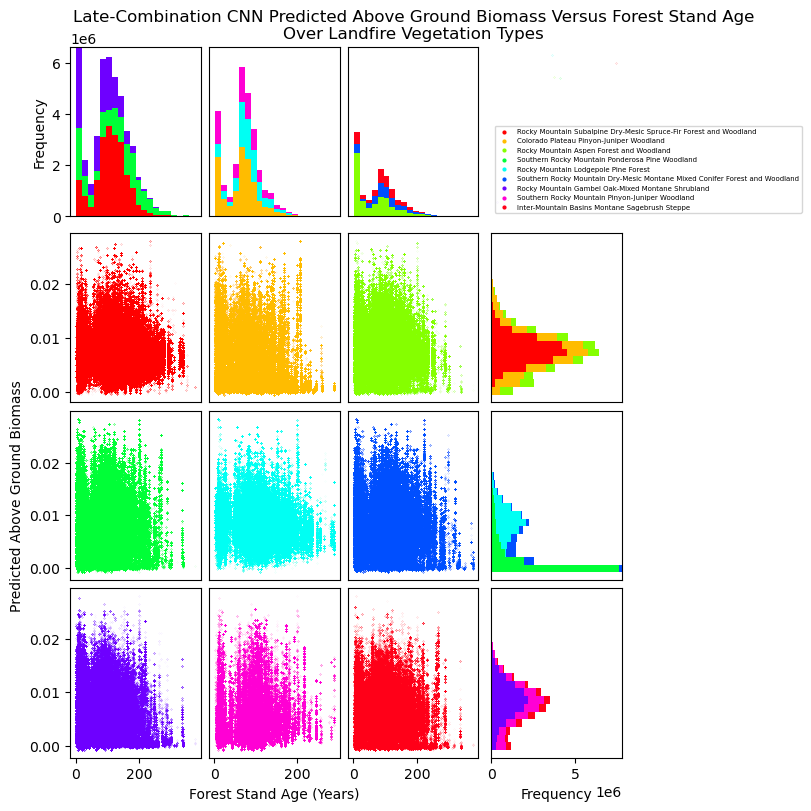

In [ ]:
xkeys = ["lf_cc", "lf_evc", "standage"]
ykeys = ["yhat_wue", "yhat_esi", "yhat_agb"]
nice_x_names = ["Landfire Canopy Cover (Percent)", "Landfire Existing Vegetation Cover (Percent)", "Forest Stand Age (Years)"]
nice_y_names = ["Predicted Water Use Efficiency", "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass"]
nice_x_title = ["Landfire Canopy Cover ", "Landfire Existing Vegetation Cover", "Forest Stand Age"]

colorsm = plt.cm.get_cmap('hsv', 9)
nbins_each = 20
ngrid = 3

for xkey in range(len(xkeys)):
    for ykey in range(len(ykeys)):
        ### fc=colorsm(i)
        #fig = plt.figure(layout='constrained', figsize=(8, 6))
        #ax = fig.add_subplot()
        #ax.set_aspect('equal')

        fig, axs = plt.subplots(ngrid+1, ngrid+1, layout='constrained', figsize=(8, 8), gridspec_kw = {'wspace': 0, 'hspace':0})#, sharex=True, sharey=True)

        #fig = plt.figure(layout='constrained')#, figsize=(8, 6))
        #axs = []
        ax_histxs = []
        ax_histys = []
        
        gridhisty = [[] for ii in range(ngrid)]
        gridhistx = [[] for ii in range(ngrid)]
        gridcoloy = [[] for ii in range(ngrid)]
        gridcolox = [[] for ii in range(ngrid)]

        gridctr = 0
        ### iterate over rows?
        for i in range(ngrid):
            ### iterate over cols
            for j in range(ngrid):
                if True:
                    axs[i+1, j].scatter(uniqueset[nine_keys[gridctr]][0][:,xkey+4], uniqueset[nine_keys[gridctr]][0][:,ykey+1], s=0.01, 
                                alpha=0.2, label=uniqueset[nine_keys[gridctr]][1][0], 
                                color=colorsm(gridctr))
                    ### for legend
                    axs[0, ngrid].scatter(uniqueset[nine_keys[gridctr]][0][:1,xkey+4], uniqueset[nine_keys[gridctr]][0][:1,ykey+1], s=0.01, 
                                label=uniqueset[nine_keys[gridctr]][1][0], 
                                color=colorsm(gridctr))
                gridhistx[i].append(uniqueset[nine_keys[gridctr]][0][:,xkey+4])
                gridhisty[j].append(uniqueset[nine_keys[gridctr]][0][:,ykey+1])

                #gridcolox[i].append((uniqueset[nine_keys[gridctr]][1][1], 
                #                     uniqueset[nine_keys[gridctr]][1][2], 
                #                     uniqueset[nine_keys[gridctr]][1][3], 1))
                #gridcoloy[j].append((uniqueset[nine_keys[gridctr]][1][1], 
                #                     uniqueset[nine_keys[gridctr]][1][2], 
                #                     uniqueset[nine_keys[gridctr]][1][3], 1))

                gridcolox[j].append(colorsm(gridctr))
                gridcoloy[i].append(colorsm(gridctr))

                if j != 0:
                    axs[i+1,j].set_yticks([])
                if i+1 != ngrid:
                    axs[i+1,j].set_xticks([])
                #axs[i+1, j].legend(loc='lower left', bbox_to_anchor=(1.02 + (i/10), 1.02), markerscale=10)
                ##loc='lower left', bbox_to_anchor=(1.02, 1.02), prop={'size': 5},markerscale=10
                gridctr += 1
        axs[0, ngrid].legend(loc='lower left', bbox_to_anchor=(0, 0), markerscale=20, prop={'size': 5})
        axs[0, ngrid].axis('off')
        #x_min = []
        #y_min = []
        x_max = []
        y_max = []
        for ng in range(ngrid):
            (ngnx, ngbinsx, ngpatchesx) = axs[0, ng].hist(gridhistx[ng], nbins_each, histtype='bar', stacked=True, log=False, color=gridcolox[ng]) #density=True
            ### Axes.set_xbound(lower=None, upper=None)
            #x_min.append(min(ngnx))
            #print(ngnx)
            x_max.append(np.max(ngnx))
            (ngny, ngbinsy, ngpatchesy) = axs[ng+1, ngrid].hist(gridhisty[ng], nbins_each, histtype='bar', stacked=True, log=False, orientation='horizontal', color=gridcoloy[ng])
            #y_min.append(min(ngny))
            #print(ngny)
            y_max.append(np.max(ngny))
            axs[0, ng].set_xticks([])
            axs[ng+1, ngrid].set_yticks([])
            if ng != 0:
                axs[0, ng].set_yticks([])
            if ng+1 != ngrid:
                axs[ng+1, ngrid].set_xticks([])
        true_y_max = max(y_max)
        true_x_max = max(x_max)
        #print(max(x_max), max(y_max))
        for ng in range(ngrid):
            axs[0, ng].set_ybound(0, true_x_max)
            axs[ng+1, ngrid].set_xbound(0, true_y_max)
        
        axs[ngrid, 1].set_xlabel(nice_x_names[xkey])
        axs[2, 0].set_ylabel(nice_y_names[ykey])
        axs[0, 0].set_ylabel("Frequency")
        axs[ngrid, ngrid].set_xlabel("Frequency")
        axs[0, 2].set_title("Late-Combination CNN " + nice_y_names[ykey] + " Versus " + nice_x_title[xkey] + "\nOver Landfire Vegetation Types")

        plt.savefig("../visualize/covars/9sq_" + xkeys[xkey] + "_" + ykeys[ykey] + ".png", bbox_inches = 'tight')

In [319]:
for i in range(9):
    print(nine_keys[i])
    #print(uniqueset[nine_keys[i]][1][0])

reorder9 = [7055.0, 7011.0, 7050.0, 7107.0, 7054.0, 7051.0, 7059.0, 7016.0]
print(reorder9)

7055.0
7016.0
7011.0
7054.0
7050.0
7051.0
7107.0
7059.0
7126.0
[7055.0, 7011.0, 7050.0, 7107.0, 7054.0, 7051.0, 7059.0, 7016.0]


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/2110201887.py:4: SyntaxWarning: invalid escape sequence '\m'
  nice_y_names = ["Predicted Water Use Efficiency \n (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)",
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/2110201887.py:5: SyntaxWarning: invalid escape sequence '\m'
  "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass \n (Mg ha$\mathregular{^{-1}}$)"]
/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_95054/2110201887.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colorsm = plt.cm.get_cmap('hs

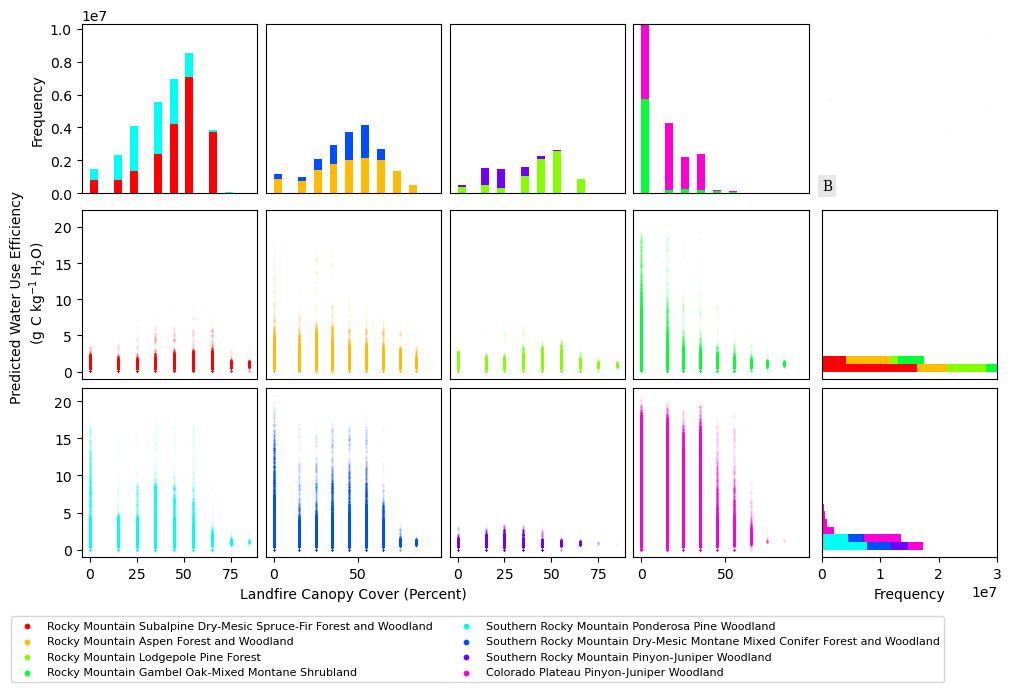

In [ ]:
xkeys = ["lf_cc", "lf_evc", "standage"]
ykeys = ["yhat_wue", "yhat_esi", "yhat_agb"]
nice_x_names = ["Landfire Canopy Cover (Percent)", "Landfire Existing Vegetation Cover (Percent)", "Forest Stand Age (Years)"]
nice_y_names = ["Predicted Water Use Efficiency \n (g C kg$\mathregular{^{-1}}$ H$\mathregular{_2}$O)", 
                "Predicted Evaporative Stress Index", "Predicted Above Ground Biomass \n (Mg ha$\mathregular{^{-1}}$)"]
nice_x_title = ["Landfire Canopy Cover ", "Landfire Existing Vegetation Cover", "Forest Stand Age"]
#letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
letters = ["A", "D", "G", "B", "E", "H", "C", "F", "I"]
letterctr = 0
## (g C kg$\mathregular{^-1}$ H $\mathregular{_2}$ O)
## ($g C kg^{-1} H_2O$)

ngrid = [2, 4]
colorsm = plt.cm.get_cmap('hsv', 9)

for xkey in range(len(xkeys)):
    for ykey in range(len(ykeys)):
        fig, axs = plt.subplots(ngrid[0]+1, ngrid[1]+1, layout='constrained', figsize=(10, 6), gridspec_kw = {'wspace': 0, 'hspace':0})#, sharex=True, sharey=True)

        ax_histxs = []
        ax_histys = []
        
        gridhisty = [[] for ii in range(ngrid[0])]
        gridhistx = [[] for ii in range(ngrid[1])]
        gridcoloy = [[] for ii in range(ngrid[0])]
        gridcolox = [[] for ii in range(ngrid[1])]
        x_max = [[] for ii in range(ngrid[1])]
        y_max = [[] for ii in range(ngrid[0])]
        gridctr = 0
        ### iterate over rows?
        for i in range(ngrid[0]):
            ### iterate over cols
            for j in range(ngrid[1]):
                if True:
                    axs[i+1, j].scatter(uniqueset[reorder9[gridctr]][0][:,xkey+4], uniqueset[reorder9[gridctr]][0][:,ykey+1], s=0.01, 
                                alpha=0.2, #label=uniqueset[reorder9[gridctr]][1][0], 
                                color=colorsm(gridctr))
                    ### for legend
                    axs[0, ngrid[1]].scatter(uniqueset[reorder9[gridctr]][0][:1,xkey+4], uniqueset[reorder9[gridctr]][0][:1,ykey+1], s=0.001, 
                                label=uniqueset[reorder9[gridctr]][1][0], 
                                color=colorsm(gridctr))
                    
                gridhistx[j].append(uniqueset[reorder9[gridctr]][0][:,xkey+4])
                gridhisty[i].append(uniqueset[reorder9[gridctr]][0][:,ykey+1])

                gridcolox[j].append(colorsm(gridctr))
                gridcoloy[i].append(colorsm(gridctr))

                ### this is one for each on x axis (4)... add one for each y in this x position
                x_max[j].append(np.nanmax(uniqueset[reorder9[gridctr]][0][:,xkey+4]))
                ### this is one for each on y axis (2)
                y_max[i].append(np.nanmax(uniqueset[reorder9[gridctr]][0][:,ykey+1]))

                if j != 0:
                    axs[i+1,j].set_yticks([])
                if i+1 != ngrid[0]:
                    axs[i+1,j].set_xticks([])
                #axs[i+1, j].legend(loc='lower left', bbox_to_anchor=(1.02 + (i/10), 1.02), markerscale=10)
                ##loc='lower left', bbox_to_anchor=(1.02, 1.02), prop={'size': 5},markerscale=10
                gridctr += 1
        #print(x_max)
        #print(y_max)

        #axs[0, ngrid[1]].text(0, 0, letters[letterctr], fontsize=40,
        #verticalalignment='bottom', horizontalalignment='left')#, bbox=props)
        
        for i in range(ngrid[0]):
            supermax = max(y_max[i])
            superdiff = supermax * 0.05
            for j in range(ngrid[1]):
                axs[i+1, j].set_ybound(-superdiff, supermax + superdiff)
        for j in range(ngrid[1]):
            supermax = max(x_max[j])
            superdiff = supermax * 0.05
            for i in range(ngrid[0]):
                axs[i+1, j].set_xbound(-superdiff, supermax+superdiff)
        #x_min = []
        #y_min = []
        x_max = []
        y_max = []
        for ng in range(ngrid[1]):
            (ngnx, ngbinsx, ngpatchesx) = axs[0, ng].hist(gridhistx[ng], nbins_each, histtype='bar', stacked=True, log=False, color=gridcolox[ng]) #density=True
            x_max.append(np.max(ngnx))
            axs[0, ng].set_xticks([])
            if ng != 0:
                axs[0, ng].set_yticks([])
        for ng in range(ngrid[0]):
            (ngny, ngbinsy, ngpatchesy) = axs[ng+1, ngrid[1]].hist(gridhisty[ng], nbins_each, histtype='bar', stacked=True, log=False, orientation='horizontal', color=gridcoloy[ng])
            y_max.append(np.max(ngny))
            axs[ng+1, ngrid[1]].set_yticks([])
            if ng+1 != ngrid[0]:
                axs[ng+1, ngrid[1]].set_xticks([])
        true_y_max = max(y_max)
        true_x_max = max(x_max)
        #print(max(x_max), max(y_max))
        for ng in range(ngrid[0]):
            axs[ng+1, ngrid[1]].set_xbound(0, true_y_max)
        for ng in range(ngrid[1]):
            axs[0, ng].set_ybound(0, true_x_max)
        
        axs[ngrid[0], 1].set_xlabel(nice_x_names[xkey])
        axs[1, 0].set_ylabel(nice_y_names[ykey])
        axs[0, 0].set_ylabel("Frequency")
        axs[ngrid[0], ngrid[1]].set_xlabel("Frequency")

        fig.legend(loc='upper left', bbox_to_anchor=(0, -0.01), ncol=2, markerscale=100, prop={'size': 8})
        axs[0, ngrid[1]].annotate(letters[letterctr], xy=(0.2, 0.2), xycoords='axes fraction', textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='left', fontfamily='serif',
        bbox=dict(facecolor='0.9', edgecolor='none', pad=3.0))
        #axs[0, ngrid[1]].legend(loc='lower right', bbox_to_anchor=(0.05, 1.05), fancybox=True, shadow=True, 
        #                        ncol=2, markerscale=10, prop={'size': 5})
        #axs[0, ngrid[1]].legend(loc='lower left', bbox_to_anchor=(0, 0), markerscale=20, prop={'size': 5})
        axs[0, ngrid[1]].axis('off')
        #axs[0, 3].set_title("Late-Combination CNN " + nice_y_names[ykey] + " Versus " + nice_x_title[xkey] + "\nOver Landfire Vegetation Types")

        plt.savefig("../visualize/covars/8box_" + xkeys[xkey] + "_" + ykeys[ykey] + ".png", bbox_inches = 'tight')
        letterctr += 1
        break
    break


In [402]:
nflights = 10
(300 + (15.31 * nflights)) / nflights

45.31

In [1]:
import numpy as np

In [2]:
x = np.array([1, 2, 3, 4])